<a href="https://colab.research.google.com/github/abdou-majeed/Logistics-auditor/blob/main/Logistics_auditor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The "Last Mile" Logistics Auditor

We try to understand the recent spike in negative customer reviews at Veridi Logistics, a Global E-Commerce Aggregator that manages shipping accross Brazil, for thousands of online sellers.
In particular, we explore these three points:
1. Is the spike in negative reviews due to a failure to deliver packages on time?
2. How often are packages late? Would pushing the expected delivery date by a few days significantly improve the rate of on-time deliveries?
3. Are the late deliveries most common in specific states? Are they due to long distances between buyers and sellers?
4. (User's choice) What part of the process is the bottleneck for delayed deliveries?

We proceed in the following steps:
- Find the general proportion of late deliveries and display the proportion per state on a map of Brazil.
- Check if the distance between buyer and seller significantly affects the delivery.
- Check the correlation between delivery performance and customer satisfaction.
- Plot the duration of each stage of the process against delivery delay to spot the part that causes the delay.


In [1]:
import os
import math
import numpy as np
import pandas as pd
import geopandas as gpd # used to display data on a map of Brazil
import matplotlib.pyplot as plt
from geopy.distance import geodesic # used to compute the distance (in km) between two locations given their latitudes and longitudes

In [2]:
np.random.seed(42) # for reproducibility

In [3]:
filenames = [filename for filename in os.listdir() if filename.endswith('.csv')]
print(f"{len(filenames)} '.csv' files found:")
for filename in filenames:
    print(f"  - {filename!r}")

9 '.csv' files found:
  - 'olist_products_dataset.csv'
  - 'product_category_name_translation.csv'
  - 'olist_orders_dataset.csv'
  - 'olist_geolocation_dataset.csv'
  - 'olist_customers_dataset.csv'
  - 'olist_order_payments_dataset.csv'
  - 'olist_order_reviews_dataset.csv'
  - 'olist_order_items_dataset.csv'
  - 'olist_sellers_dataset.csv'


A preliminary exploration of the datasets was performed.
Here are a few remarks worth taking into account.

1. ``olist_orders_dataset`` is the central dataset.
It analysis reveals that every order goes through the following steps.

- ``created`` -> ``approved``, ``processing``, ``invoiced`` -> ``shipped`` -> ``delivered``. The order within approved-processing-invoiced could not be inferred from the data.
- An alternative is ``created`` -> ``approved`` -> ``unavailable``.
- The last possibility is ``created`` [-> Any ]-> ``canceled``. Orders can be canceled at any time, apparently even after delivery.

2. Some delivered orders don't have (customer or carrier) delivery dates, or ``approved_at`` date. It is most likely a mistake and it is uncommon (~10 orders), so we remove those orders from our analysis.

3. In ``olist_order_reviews_dataset``,

- the same ``review_id`` can correspond to two different orders.
Strangely, in such cases the two rows differ only by their ``order_id`` which suggests a mistake. There is unfortunately not enough information to clean that up, and it is not uncommon (800+ distincts review_id). We keep all such reviews in the dataset.

- two different reviews can correspond to the same ``order_id``.
In the [discussions on Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce/discussion/475296), the source/author of the dataset explained that as several items can be included in the same order, they can also be delivered separately thereby reviewed on separate occasions.
That structure of the data is unfortunate because we cannot confidently perform the analysis of reviews vs. orders or order_items, especially given that the order dataset only shows one delivery_date per order.
We also ignore all that and simply keep the data as it is for our analysis.

4. The ``olist_geolocation_dataset``: From the documentation of the dataset,
it appears the zip code prefixes are not a unique identifier for a location. Several latitute-longitude pairs can be assigned the same zip code prefix.
The worst is that for the same zip code prefix, the range of values of latitude and longitude can be so large as to cover 7000 kilometers (70 degrees), and that is not uncommon: more than 200 zip codes have ranges beyond 100 km. Unfortunately, no free dataset could be found online that covered all zip codes neededd. An attempt to use the location of cities instead also failed because there are some duplicate names that cannot be easily handled (eg. 'sao paulo' and 'são paulo' are two different cities in the dataset).
Ultimately, we use the median latitude and longitude to estimate the location of each zip code prefix, and only consider the zip codes whose latitudes and longitudes have an inter-quartile range of at most 0.1 degree (~10km).

# Story 1: The Schema Builder

**As a** Data Engineer,
**I want** to join the Orders, Reviews, and Customers tables into a single master dataset,
**So that** I can analyze a customer's location and their review score in the same row.

- **Acceptance Criteria:**
  - Load the raw CSVs into your notebook.
  - Perform the correct joins (e.g., join Reviews to Orders on `order_id`, join Customers to Orders on `customer_id`).
  - **Check:** Ensure you don't accidentally duplicate rows (a common error with 1-to-many joins).


In [4]:
[filename for filename in os.listdir() if filename.endswith('.csv')]

['olist_products_dataset.csv',
 'product_category_name_translation.csv',
 'olist_orders_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_customers_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_sellers_dataset.csv']

In [5]:
Orders    = pd.read_csv('olist_orders_dataset.csv')
Customers = pd.read_csv('olist_customers_dataset.csv')
Reviews   = pd.read_csv('olist_order_reviews_dataset.csv')

In [6]:
# Drop duplicates from every dataset
for name, dataset in {"Orders": Orders, "Customers": Customers, "Reviews": Reviews}.items():
    dataset.drop_duplicates(inplace=True)
    print()
    print(f"====================== {name} ======================")
    dataset.info()


====================== Orders ======================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

====================== Customers ======================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Cou

``orders`` is the central dataset, so when joining it with other tables, we insure that all its rows are kept.

In [7]:
master_dataset = pd.merge(Orders, Customers, on="customer_id", how="left", suffixes=["_ORDERS", "_CUSTOMERS"])
master_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
 8   customer_unique_id             99441 non-null  object
 9   customer_zip_code_prefix       99441 non-null  int64 
 10  customer_city                  99441 non-null  object
 11  customer_state                 99441 non-null  object
dtypes: int64(1), object(11)
memory usage: 9.1+ MB


In [8]:
master_dataset = pd.merge(master_dataset, Reviews, on="order_id", how="left", suffixes=["", "_REVIEWS"])
master_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99992 entries, 0 to 99991
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99992 non-null  object 
 1   customer_id                    99992 non-null  object 
 2   order_status                   99992 non-null  object 
 3   order_purchase_timestamp       99992 non-null  object 
 4   order_approved_at              99831 non-null  object 
 5   order_delivered_carrier_date   98199 non-null  object 
 6   order_delivered_customer_date  97005 non-null  object 
 7   order_estimated_delivery_date  99992 non-null  object 
 8   customer_unique_id             99992 non-null  object 
 9   customer_zip_code_prefix       99992 non-null  int64  
 10  customer_city                  99992 non-null  object 
 11  customer_state                 99992 non-null  object 
 12  review_id                      99224 non-null 

In [9]:
# Are there duplicates in the master dataset?
master_dataset[master_dataset.duplicated()].shape

(0, 18)

Therefore, there is **no duplicate** in ``master_dataset``.

However, from the initial exploration of the datasets, we know that

- there can be several orders per review_id,
- and there can be several reviews for the same order.

# Story 2: The "Real" Delay Calculator

**As a** Logistics Manager,
**I want** to know the difference between the "Estimated Delivery Date" and the "Actual Delivery Date,"
**So that** I can see how often we are lying to customers.

- **Acceptance Criteria:**
  - Create a new calculated column: `Days_Difference` = `order_estimated_delivery_date` - `order_delivered_customer_date`.
  - Classify orders into statuses: "On Time", "Late", and "Super Late" (> 5 days late).
  - Handle missing values: Some orders were never delivered (`order_status` = 'canceled' or 'unavailable'). These should be excluded or flagged separately.


We group the orders into three categories:

- ``delivered``: orders with order_status ``delivered``,

- ``incomplete``: orders with order_status among ``created, approved, processing, invoiced, shipped``,

- ``interupted``: orders with order_status among ``unavailable, canceled``.

We then compute the ``Days_Difference`` for the ``delivered`` group, with the formula:
``order_estimated_delivery_date - order_delivered_customer_date``.
Therefore, a positive value means the order was on time and a negative one means it was late.
We classify the delivered orders into the classes "On Time", "Late", and "Super Late" (more than five days late).

For simplicity, we do not perform a similar analysis on the ``interupted`` orders.

For the ``incomplete`` ones, we choose as ``order_delivered_customer_date``, the latest date of any event in the dataset.

At the end, we get to choose wether to include the incomplete orders in the next analysis or to stick to only the delivered ones.

In [10]:
delivered  = master_dataset[master_dataset.order_status == "delivered"].copy()
incomplete = master_dataset[master_dataset.order_status.isin(("created", "approved", "processing", "invoiced", "shipped"))].copy()
interupted = master_dataset[master_dataset.order_status.isin(("canceled", "unavailable"))].copy()

In [11]:
assert len(delivered) + len(incomplete) + len(interupted) == len(master_dataset), "Something is wrong! Verify you splitted the dataset correctly."

## ``delivered``

In [12]:
delivered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97007 entries, 0 to 99991
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       97007 non-null  object 
 1   customer_id                    97007 non-null  object 
 2   order_status                   97007 non-null  object 
 3   order_purchase_timestamp       97007 non-null  object 
 4   order_approved_at              96993 non-null  object 
 5   order_delivered_carrier_date   97005 non-null  object 
 6   order_delivered_customer_date  96999 non-null  object 
 7   order_estimated_delivery_date  97007 non-null  object 
 8   customer_unique_id             97007 non-null  object 
 9   customer_zip_code_prefix       97007 non-null  int64  
 10  customer_city                  97007 non-null  object 
 11  customer_state                 97007 non-null  object 
 12  review_id                      96361 non-null  obje

In [13]:
# Some 'order_delivered_customer_date' are null in 'delivered'. Remove those rows.
delivered = delivered[delivered.order_delivered_customer_date.notna()]
delivered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96999 entries, 0 to 99991
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       96999 non-null  object 
 1   customer_id                    96999 non-null  object 
 2   order_status                   96999 non-null  object 
 3   order_purchase_timestamp       96999 non-null  object 
 4   order_approved_at              96985 non-null  object 
 5   order_delivered_carrier_date   96998 non-null  object 
 6   order_delivered_customer_date  96999 non-null  object 
 7   order_estimated_delivery_date  96999 non-null  object 
 8   customer_unique_id             96999 non-null  object 
 9   customer_zip_code_prefix       96999 non-null  int64  
 10  customer_city                  96999 non-null  object 
 11  customer_state                 96999 non-null  object 
 12  review_id                      96353 non-null  obje

In [14]:
# Convert the relevant columns to datetime, and make sure no null value was introduced during conversion
delivered["order_delivered_customer_date"] = pd.to_datetime(delivered["order_delivered_customer_date"])
delivered["order_estimated_delivery_date"] = pd.to_datetime(delivered["order_estimated_delivery_date"])

if delivered[delivered.order_delivered_customer_date.isna()].size == 0:
    print("All right: order_delivered_customer_date converted successfully")
else:
    print("Issues with order_delivered_customer_date")

if delivered[delivered.order_estimated_delivery_date.isna()].size == 0:
    print("All right: order_estimated_delivery_date converted successfully")
else:
    print("Issues with order_estimated_delivery_date")

All right: order_delivered_customer_date converted successfully
All right: order_estimated_delivery_date converted successfully


In [15]:
delivered[["order_delivered_customer_date", "order_estimated_delivery_date"]].sample(5)

,order_delivered_customer_date,order_estimated_delivery_date
58289,2017-11-16 18:49:49,2017-11-28
6243,2018-05-03 14:03:48,2018-05-18
90045,2017-04-11 13:32:04,2017-04-28
18952,2017-07-24 17:12:26,2017-08-07
46853,2018-07-10 18:59:45,2018-07-31


In [16]:
# Days_Difference
delivered["Days_Difference"] = delivered.order_estimated_delivery_date - delivered.order_delivered_customer_date
delivered[["order_delivered_customer_date", "order_estimated_delivery_date", "Days_Difference"]].sample(5)

,order_delivered_customer_date,order_estimated_delivery_date,Days_Difference
20234,2018-06-12 23:11:39,2018-06-28,15 days 00:48:21
56805,2017-10-20 22:30:03,2017-11-03,13 days 01:29:57
37778,2017-08-24 16:03:31,2017-08-30,5 days 07:56:29
87796,2017-09-26 21:42:41,2017-10-06,9 days 02:17:19
35795,2017-08-08 21:52:11,2017-08-30,21 days 02:07:49


In [17]:
# Group into statuses
zero = pd.Timedelta(0)
neg_five_days = pd.Timedelta(days=-5)

In [18]:
delivered["delivery_status"] = "On Time"
delivered.loc[delivered.Days_Difference < zero, "delivery_status"] = "Late"
delivered.loc[delivered.Days_Difference < neg_five_days, "delivery_status"] = "Super Late"

In [19]:
np.random.seed(63530) # for reproducibility
delivered[["Days_Difference", "delivery_status"]].sample(10)

,Days_Difference,delivery_status
79946,6 days 08:11:21,On Time
13215,-5 days +03:56:41,Late
21940,14 days 12:41:15,On Time
60385,27 days 22:31:17,On Time
95384,1 days 04:20:52,On Time
63201,15 days 05:35:17,On Time
61169,14 days 13:02:26,On Time
77551,13 days 01:38:25,On Time
71541,0 days 11:03:17,On Time
33039,-13 days +00:52:51,Super Late


In [20]:
delivered.delivery_status.value_counts()

,count
delivery_status,
On Time,89134
Super Late,4234
Late,3631


## ``incomplete``

Incomplete orders do not have an ``order_delivered_customer_date``.

To fix that, we will find the latest date of any event in the master_dataset.
An event is any of "purchase, approved, delivered_carrier, delivered_customer, review_creation, review_answer".

We know that the present date is later than the lastest date that appears in the dataset, where present date is the date at which the dataset was extracted.

``order_delivered_customer_date`` will be set to that value.

In [21]:
incomplete.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1745 entries, 6 to 99864
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       1745 non-null   object 
 1   customer_id                    1745 non-null   object 
 2   order_status                   1745 non-null   object 
 3   order_purchase_timestamp       1745 non-null   object 
 4   order_approved_at              1740 non-null   object 
 5   order_delivered_carrier_date   1118 non-null   object 
 6   order_delivered_customer_date  0 non-null      object 
 7   order_estimated_delivery_date  1745 non-null   object 
 8   customer_unique_id             1745 non-null   object 
 9   customer_zip_code_prefix       1745 non-null   int64  
 10  customer_city                  1745 non-null   object 
 11  customer_state                 1745 non-null   object 
 12  review_id                      1657 non-null   objec

In [22]:
incomplete.order_status.value_counts()

,count
order_status,
shipped,1118
invoiced,318
processing,302
created,5
approved,2


In [23]:
date_event_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    # "order_estimated_delivery_date", # this is not an event!!
    "review_creation_date",
    "review_answer_timestamp",
]

In [24]:
# Copy the events date from the master dataset, and convert them to datetime
tmp = master_dataset.copy()[date_event_columns]
for col in date_event_columns:
    tmp[col] = pd.to_datetime(tmp[col])
tmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99992 entries, 0 to 99991
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_purchase_timestamp       99992 non-null  datetime64[ns]
 1   order_approved_at              99831 non-null  datetime64[ns]
 2   order_delivered_carrier_date   98199 non-null  datetime64[ns]
 3   order_delivered_customer_date  97005 non-null  datetime64[ns]
 4   review_creation_date           99224 non-null  datetime64[ns]
 5   review_answer_timestamp        99224 non-null  datetime64[ns]
dtypes: datetime64[ns](6)
memory usage: 4.6 MB


In [25]:
# Find the date of the last event
latest_event_date = tmp.max().max()
latest_event_date

Timestamp('2018-10-29 12:27:35')

In [26]:
# Convert relevant columns of 'incomplete' to datetime, and make sure no null value was introduced by the conversion
# Set order_delivered_customer_date to latest_event_date
incomplete["order_estimated_delivery_date"] = pd.to_datetime(incomplete["order_estimated_delivery_date"])
incomplete["order_delivered_customer_date"] = latest_event_date

if delivered[delivered.order_estimated_delivery_date.isna()].size == 0:
    print("All right: order_estimated_delivery_date converted sucessfully")
else:
    print("Issues with order_estimated_delivery_date")
print()

All right: order_estimated_delivery_date converted sucessfully



In [27]:
# Days_Difference
incomplete["Days_Difference"] = incomplete.order_estimated_delivery_date - incomplete.order_delivered_customer_date

In [28]:
incomplete[["order_delivered_customer_date", "order_estimated_delivery_date", "Days_Difference"]].sample(5)

,order_delivered_customer_date,order_estimated_delivery_date,Days_Difference
85768,2018-10-29 12:27:35,2017-08-23,-433 days +11:32:25
4745,2018-10-29 12:27:35,2017-06-01,-516 days +11:32:25
44454,2018-10-29 12:27:35,2017-12-12,-322 days +11:32:25
23719,2018-10-29 12:27:35,2017-05-10,-538 days +11:32:25
65253,2018-10-29 12:27:35,2018-08-08,-83 days +11:32:25


In [29]:
# Set statuses
incomplete["delivery_status"] = "On Time"
incomplete.loc[incomplete.Days_Difference < zero, "delivery_status"] = "Late"
incomplete.loc[incomplete.Days_Difference < neg_five_days, "delivery_status"] = "Super Late"
incomplete[["Days_Difference", "delivery_status"]].sample(10)

,Days_Difference,delivery_status
31293,-595 days +11:32:25,Super Late
61586,-501 days +11:32:25,Super Late
92932,-322 days +11:32:25,Super Late
91924,-524 days +11:32:25,Super Late
80435,-369 days +11:32:25,Super Late
87700,-291 days +11:32:25,Super Late
94527,-363 days +11:32:25,Super Late
68577,-371 days +11:32:25,Super Late
74476,-151 days +11:32:25,Super Late
48170,-257 days +11:32:25,Super Late


In [30]:
# Are all incomplete orders "Super Late"?
incomplete.delivery_status.unique()

array(['Super Late'], dtype=object)

All incomplete orders are "Super Late".

That means those orders were not being carried out. They were stopped for reasons that are not specified in the dataset.

## Combine them

In [31]:
delivered.shape

(96999, 20)

In [32]:
incomplete.shape

(1745, 20)


Adding ``incomplete``
(1700+ Super Late) to
``delivered`` (<4000 Super Late)
might not be right.
It would significantly change the analysis.

In [33]:
# delay_data = pd.concat([delivered, incomplete])
delay_data = delivered

In [34]:
delay_data.shape

(96999, 20)

In [35]:
delay_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96999 entries, 0 to 99991
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       96999 non-null  object         
 1   customer_id                    96999 non-null  object         
 2   order_status                   96999 non-null  object         
 3   order_purchase_timestamp       96999 non-null  object         
 4   order_approved_at              96985 non-null  object         
 5   order_delivered_carrier_date   96998 non-null  object         
 6   order_delivered_customer_date  96999 non-null  datetime64[ns] 
 7   order_estimated_delivery_date  96999 non-null  datetime64[ns] 
 8   customer_unique_id             96999 non-null  object         
 9   customer_zip_code_prefix       96999 non-null  int64          
 10  customer_city                  96999 non-null  object         
 11  custome

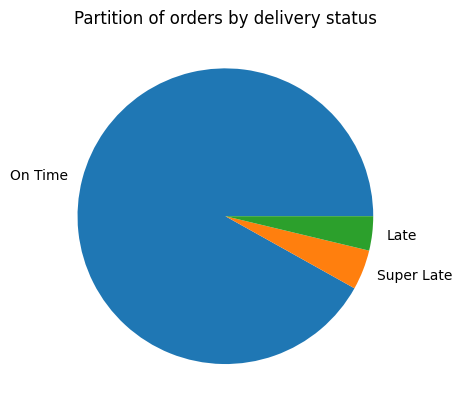

In [36]:
delay_data.delivery_status.value_counts().plot.pie()
plt.title("Partition of orders by delivery status")
plt.ylabel("")
plt.savefig("Partition of orders by delivery status.eps", format='eps', transparent=True)
plt.show()

In [37]:
100* delay_data.delivery_status.value_counts() / len(delay_data.delivery_status)

,count
delivery_status,
On Time,91.891669
Super Late,4.364993
Late,3.743338


# Story 3: The Geographic Heatmap

**As a** Regional Director,
**I want** to see which specific States (`customer_state`) have the highest percentage of late deliveries,
**So that** I can focus my repair efforts on the worst regions.

- **Acceptance Criteria:**
  - Calculate the % of late orders per State.
  - Visualize this on a map or a bar chart.
  - **Insight:** Identify if "Remote" states (far from the distribution center) are disproportionately affected.


In this section we do the following.

- For each state, we find the proportion of the orders delivered to that state that were late. We plot the result on a map of Brazil.

- For each order, we compute the distance between the buyer and sellers then plot the delivery delay as a function of this distance.

## Late Orders Per State

In [38]:
total_deliveries_per_state = delay_data["customer_state"].value_counts()
total_deliveries_per_state.head()

,count
customer_state,
SP,40705
RJ,12420
MG,11423
RS,5381
PR,4942


In [39]:
late_deliveries_per_state = delay_data[delay_data.delivery_status != "On Time"]["customer_state"].value_counts()
late_deliveries_per_state.head()

,count
customer_state,
SP,2393
RJ,1674
MG,640
BA,461
RS,386


In [40]:
tmp = pd.merge(total_deliveries_per_state, late_deliveries_per_state, on="customer_state", how="left", suffixes=["_TOTAL", "_LATE"])
tmp.head()

,count_TOTAL,count_LATE
customer_state,,
SP,40705,2393
RJ,12420,1674
MG,11423,640
RS,5381,386
PR,4942,248


In [41]:
percentage_late_deliveries_per_state = 100 * tmp.count_LATE / tmp.count_TOTAL
percentage_late_deliveries_per_state.name = "percentage"
percentage_late_deliveries_per_state.sort_values(ascending=False).head()

,percentage
customer_state,
AL,23.940150
MA,19.556172
PI,15.932914
CE,15.366615
SE,15.223881


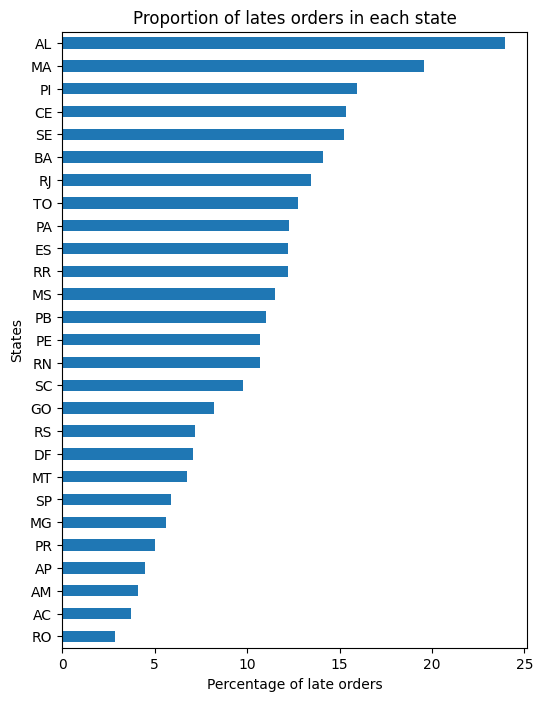

In [42]:
plt.figure(figsize=(6,8))
percentage_late_deliveries_per_state.sort_values().plot.barh()
plt.ylabel("States")
plt.xlabel("Percentage of late orders")
plt.title("Proportion of lates orders in each state")
plt.savefig("Proportion of lates orders in each state.eps", format="eps", transparent=True)
plt.show()

To visualize on a map, we use the shapefiles for Brazilian states from https://www.kaggle.com/datasets/rodsaldanha/brazilianstatesshapefiles

Include them in a folder ``map`` in the current directory, then run the code below.

/tmp/ipykernel_10752/4157519362.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


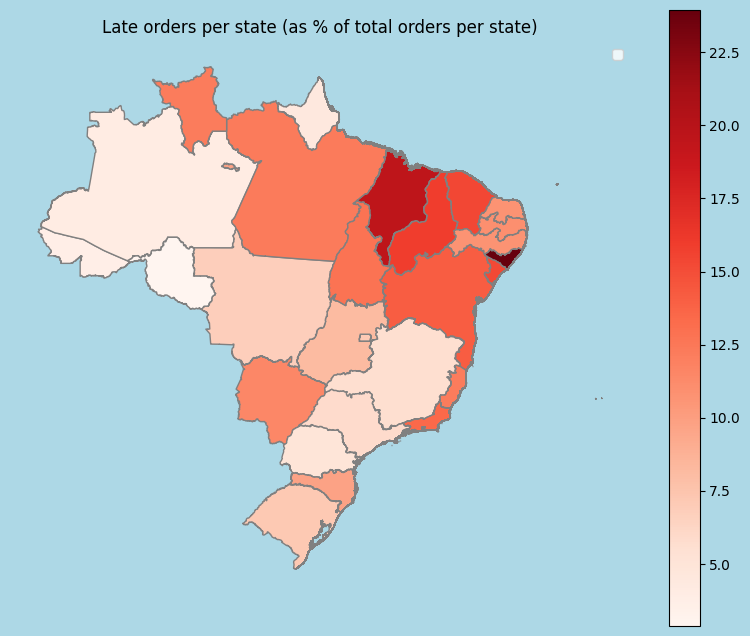

In [43]:
# Visualize on a map
if 'map' in os.listdir():
    tmp = percentage_late_deliveries_per_state.copy()
    tmp.index = ["BR."+key for key in tmp.index] # prefix with BR.
    tmp.index.name = "States"
    # tmp.head()

    brazil_map = gpd.read_file('map/BRA_adm1.shp')
    # brazil_map.head()
    brazil_map = pd.merge(brazil_map, tmp, left_on="HASC_1", right_on="States", how="left")

    fig, ax = plt.subplots(1, figsize=(10,8), facecolor ='lightblue')
    brazil_map.plot(ax = ax, column ='percentage', cmap ='Reds', edgecolors ='grey', legend=True)
    ax.axis('off')
    plt.title("Late orders per state (as % of total orders per state)")
    plt.legend()
    plt.savefig('Late orders per state (as % of total orders per state).eps', format='eps', transparent=True)
    plt.show()
else:
    print("To visualize on a map, we use the shapefiles for Brazilian states from")
    print("https://www.kaggle.com/datasets/rodsaldanha/brazilianstatesshapefiles")
    print("Include them in a folder `map` in the current directory, then run this cell again.")

## Late Orders vs. Buyer-Sellers distances

In [44]:
Geolocation = pd.read_csv('olist_geolocation_dataset.csv')
Geolocation.sample(5)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
453641,22630,-23.009040,-43.355229,rio de janeiro,RJ
499784,26580,-22.787126,-43.423617,mesquita,RJ
773456,68742,-1.287728,-47.923860,castanhal,PA
544540,30180,-19.921635,-43.954394,belo horizonte,MG
178168,7023,-23.476548,-46.542099,guarulhos,SP


In [45]:
Geolocation.drop_duplicates(inplace=True)

In [46]:
Geolocation.info()

<class 'pandas.core.frame.DataFrame'>
Index: 738332 entries, 0 to 1000161
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  738332 non-null  int64  
 1   geolocation_lat              738332 non-null  float64
 2   geolocation_lng              738332 non-null  float64
 3   geolocation_city             738332 non-null  object 
 4   geolocation_state            738332 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 33.8+ MB


To estimate (lat, lng) for each zip code prefix,
- we group the datapoints by zip code prefix
- we remove outliers: locations with latitutde or longitude beyond $
\text{quartile} \pm 1.5~\text{IQR}$
- we remove zip codes with either $\text{IQR} > 1^\circ$ (~111km)
- we use the median latitude and the median longitude as approximation for the location represented by each zip code prefix
- we compute de distance between buyer and seller for each order
- we plot delay (in days) vs. distance.

In [47]:
tmp = Geolocation[["geolocation_zip_code_prefix", "geolocation_lat"]]\
    .groupby('geolocation_zip_code_prefix')\
    .quantile(.25)\
    .sort_values("geolocation_zip_code_prefix")
tmp.rename(columns={"geolocation_lat": "lat25"}, inplace=True)
tmp["lat_median"] = Geolocation[["geolocation_zip_code_prefix", "geolocation_lat"]]\
    .groupby('geolocation_zip_code_prefix')\
    .quantile(.5)\
    .sort_values("geolocation_zip_code_prefix")
tmp["lat75"] = Geolocation[["geolocation_zip_code_prefix", "geolocation_lat"]]\
    .groupby('geolocation_zip_code_prefix')\
    .quantile(.75)\
    .sort_values("geolocation_zip_code_prefix")
tmp["lat_IQR"] = tmp.lat75 - tmp.lat25
tmp["lat_high"] = tmp.lat75 + 1.5*tmp.lat_IQR
tmp["lat_low"] = tmp.lat25 - 1.5*tmp.lat_IQR

tmp["lng25"] = Geolocation[["geolocation_zip_code_prefix", "geolocation_lng"]]\
    .groupby('geolocation_zip_code_prefix')\
    .quantile(.25)\
    .sort_values("geolocation_zip_code_prefix")
tmp["lng_median"] = Geolocation[["geolocation_zip_code_prefix", "geolocation_lng"]]\
    .groupby('geolocation_zip_code_prefix')\
    .quantile(.5)\
    .sort_values("geolocation_zip_code_prefix")
tmp["lng75"] = Geolocation[["geolocation_zip_code_prefix", "geolocation_lng"]]\
    .groupby('geolocation_zip_code_prefix')\
    .quantile(.75)\
    .sort_values("geolocation_zip_code_prefix")
tmp["lng_IQR"] = tmp.lng75 - tmp.lng25
tmp["lng_high"] = tmp.lng75 + 1.5*tmp.lng_IQR
tmp["lng_low"] = tmp.lng25 - 1.5*tmp.lng_IQR

tmp.sample(5)

,lat25,lat_median,lat75,lat_IQR,lat_high,lat_low,lng25,lng_median,lng75,lng_IQR,lng_high,lng_low
geolocation_zip_code_prefix,,,,,,,,,,,,
64710,-7.778398,-7.778302,-7.777555,0.000844,-7.776289,-7.779664,-42.255311,-42.255018,-42.254266,0.001044,-42.252700,-42.256877
3231,-23.650802,-23.650802,-23.650802,0.000000,-23.650802,-23.650802,-46.658499,-46.658499,-46.658499,0.000000,-46.658499,-46.658499
36475,-20.769253,-20.768984,-20.767996,0.001257,-20.766110,-20.771138,-43.187897,-43.187099,-43.185638,0.002259,-43.182250,-43.191285
17026,-22.296971,-22.293974,-22.292550,0.004421,-22.285918,-22.303603,-49.051044,-49.045667,-49.041658,0.009386,-49.027578,-49.065124
31080,-19.888956,-19.885034,-19.881695,0.007261,-19.870805,-19.899847,-43.910691,-43.909241,-43.908203,0.002488,-43.904471,-43.914423


In [48]:
len(tmp)

19015

In [49]:
MiniGeo = tmp[(tmp.lat_IQR < 1) & (tmp.lng_IQR < 1)][["lat_median", "lng_median"]]
MiniGeo.sample(5)

,lat_median,lng_median
geolocation_zip_code_prefix,,
5040,-23.513045,-46.708211
95588,-29.798013,-50.045983
68371,-3.207871,-52.213942
11603,-23.731697,-45.403772
76990,-12.555419,-60.903220


Form a table with ``order_id``, ``seller_id``, ``seller_lat``, and ``seller_lng``.

In [50]:
Sellers = pd.read_csv('olist_sellers_dataset.csv')
OrderItems = pd.read_csv('olist_order_items_dataset.csv')

# Drop duplicates from every dataset
for name, dataset in {"Sellers": Sellers, "OrderItems": OrderItems}.items():
    dataset.drop_duplicates(inplace=True)
    print()
    print(f"====================== {name} ======================")
    dataset.info()


====================== Sellers ======================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB

====================== OrderItems ======================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4

In [51]:
Sellers_location = pd.merge(Sellers, OrderItems, on="seller_id", how="inner")
Sellers_location = pd.merge(Sellers_location, MiniGeo, left_on="seller_zip_code_prefix", right_on="geolocation_zip_code_prefix", how="inner")
Sellers_location = Sellers_location[["order_id", "seller_id", "lat_median", "lng_median"]]
Sellers_location.rename(columns={"lat_median": "seller_lat", "lng_median": "seller_lng"}, inplace=True)
Sellers_location.sample(5)

,order_id,seller_id,seller_lat,seller_lng
19492,f751ec155a1b03010e9ab382099e3d66,2b1a40c1daabc6ca280c4b815c101841,-20.140685,-44.887421
9680,4365613066af1c4cbe81160706a082f4,a3a38f4affed601eb87a97788c949667,-26.287217,-48.851285
99924,7beece85fb714c481300a516c9fb1ade,1f1bb1f0859883505541bdd6606193e5,-23.505966,-46.577815
45251,0fec5b52f7f6c1e7b725c742a8bdf7d4,9596c870880d900012f2e8e6e30d06d7,-21.591450,-45.443558
9114,a49dc0169f9bb6d3ac9829bdebd12299,9f505651f4a6abe901a56cdc21508025,-23.590330,-46.631751


Form a table with ``order_id``, ``buyer_id``, ``buyer_lat``, and ``buyer_lng``.

In [52]:
Buyers_location = pd.merge(master_dataset, MiniGeo, left_on="customer_zip_code_prefix", right_on="geolocation_zip_code_prefix", how="inner")
Buyers_location = Buyers_location[["order_id", "customer_id", "lat_median", "lng_median"]]
Buyers_location.rename(columns={"lat_median": "buyer_lat", "lng_median": "buyer_lng"}, inplace="True")
Buyers_location.sample(5)

,order_id,customer_id,buyer_lat,buyer_lng
47216,a648c61eff7741ba3ba3205ce0cc7630,7c60f7001195e887da64333e50289a4a,-22.015157,-47.889981
52582,51a8469438e01a912e0e55cf32fc0abb,8ed6e42fde758d7b78d7ebf1eb9bdd5d,-23.287639,-45.962214
84358,9d2aa61b374fac5dd063f36fefa602e1,6bf5d790b895c0b3dfdbc9b865ac7372,-15.851147,-47.951363
43967,b3352e49bf919f038ea9f9953bb2be4a,59923dfd7914ff594e6e16878bc19d74,-7.490822,-38.984601
30468,044223df7cb37509bfeb2a0df1250ca4,f2d67e6cf876a8f7aa9e9119415510fd,-19.532527,-54.041887


Join the two tables and compute the buyer-seller distance

In [53]:
Distance = pd.merge(Buyers_location, Sellers_location, on="order_id", how="inner")
Distance.sample(5)

,order_id,customer_id,buyer_lat,buyer_lng,seller_id,seller_lat,seller_lng
57062,ba9e135697c2fbf721ea10bb6d7c0d17,524b931bb2666da2d665da0984cafcb3,-21.701281,-43.442239,c826c40d7b19f62a09e2d7c5e7295ee2,-23.437196,-46.511212
106271,c05f96437381637362bc32cb1b54d71f,e5f0d1bc1a958e1f5236f194121f8541,-22.772433,-43.418145,9646c3513289980f17226a2fc4720dbd,-23.184770,-45.872922
42699,bbf2cbe3fa966e8988c2ff247b7a3330,e4442a167ea250dbaaf8f8056915cc9e,-22.857339,-43.451344,343e716476e3748b069f980efbaa294e,-22.904840,-47.097679
99557,26fb6c984069988017b2d12b79849865,6ad1ab20e1583a1e1d20961b363df092,-20.783912,-49.357536,dc8798cbf453b7e0f98745e396cc5616,-23.540927,-46.711927
47151,8e8b51e17eee9ba8af38266e4c242549,d8680d7af781392083d4255c8e19379f,-23.548099,-46.910348,da8622b14eb17ae2831f4ac5b9dab84a,-22.709287,-47.665524


In [54]:
def distance_function(row):
    return geodesic((row.buyer_lat, row.buyer_lng), (row.seller_lat, row.seller_lng)).km

In [55]:
Distance["distance_km"] = Distance.apply(distance_function, axis=1)
Distance = Distance[["order_id", "distance_km"]].groupby("order_id").max().sort_values(by="distance_km", ascending=False)
Distance

,distance_km
order_id,
8ad3f1d0f96992e43566c4c82c9f6c58,8652.107208
e9874f4e48ede77b6b9d785ac3755445,3564.594124
9b790ca446b8e28ce5e4382959f6b7df,3384.370053
2889d7816934298a0f5a4a30ef3ffbc7,3373.165819
ecab90c9933c58908d3d6add7c6f5ae3,3366.580845
...,...
f046579c38fc520955aa572d052cbd3c,0.000000
42a64eac09d0a6be5a307753093d45e8,0.000000
fc28aed78cb8bcd22a7dbd82cb778946,0.000000


Join the delay_data to the Distance table and plot.

In [56]:
delay_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96999 entries, 0 to 99991
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       96999 non-null  object         
 1   customer_id                    96999 non-null  object         
 2   order_status                   96999 non-null  object         
 3   order_purchase_timestamp       96999 non-null  object         
 4   order_approved_at              96985 non-null  object         
 5   order_delivered_carrier_date   96998 non-null  object         
 6   order_delivered_customer_date  96999 non-null  datetime64[ns] 
 7   order_estimated_delivery_date  96999 non-null  datetime64[ns] 
 8   customer_unique_id             96999 non-null  object         
 9   customer_zip_code_prefix       96999 non-null  int64          
 10  customer_city                  96999 non-null  object         
 11  custome

In [57]:
tmp = delay_data[["order_id", "Days_Difference", "delivery_status"]].copy()
Delay_vs_Distance = pd.merge(tmp, Distance, on="order_id", how="inner")
Delay_vs_Distance["delay_days"] = (-Delay_vs_Distance.Days_Difference).dt.days
np.random.seed(4829422)
Delay_vs_Distance.sample(10)

,order_id,Days_Difference,delivery_status,distance_km,delay_days
26656,1e16f42e33100a56e1408cceb4846f2b,17 days 05:51:02,On Time,327.423655,-18
70833,68dd7c23e8b6c1e5f3ad16be5dd4bdf6,0 days 03:40:10,On Time,21.979730,-1
32705,b84394f64014d2bc61ef7e890cf10a0a,21 days 03:46:38,On Time,837.941916,-22
76565,fa2211e05a1ebb8eedfa015e5d6d7957,6 days 07:51:56,On Time,1.623354,-7
55286,43744ad15fef908c8dfcbd7fec0d786e,-31 days +02:05:57,Super Late,570.619842,30
79164,055d54b48c1c7292933cb2e27f73ee81,19 days 06:36:57,On Time,77.702908,-20
14724,ace3b21c5c57456d2e2215452829073b,2 days 08:47:31,On Time,42.036283,-3
69755,0c8d39b03d0d4918d66be0eae8f57a58,12 days 07:21:37,On Time,538.938537,-13
8822,15cd24278cb6a373aa6bb2ca34837e16,9 days 10:33:04,On Time,451.601076,-10
91794,73573871323db760fe4f1b0c508ecff0,-5 days +12:27:29,Late,37.107351,4


Text(0, 0.5, 'delay in days - positive is late')

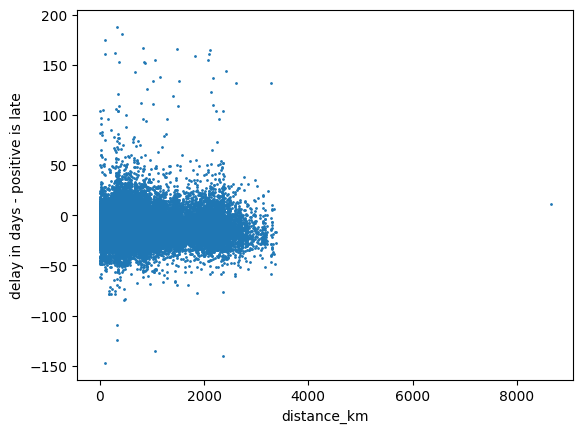

In [58]:
Delay_vs_Distance.plot.scatter(x="distance_km", y="delay_days", s=1)
plt.ylabel("delay in days - positive is late")

In [59]:
# Remove an obvious outlier
Delay_vs_Distance = Delay_vs_Distance[Delay_vs_Distance.distance_km < 4000]

<Axes: xlabel='distance_km', ylabel='delay_days'>

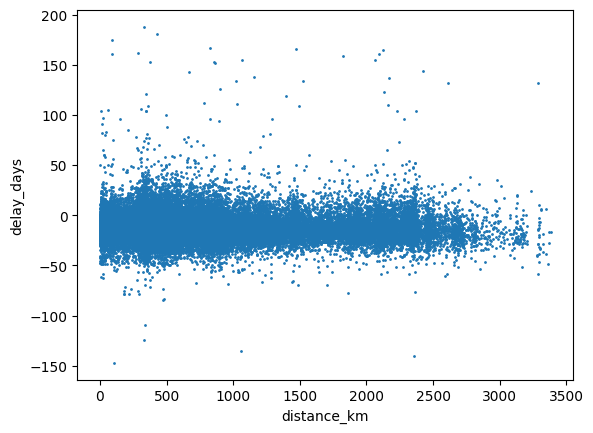

In [60]:
Delay_vs_Distance.plot.scatter(x="distance_km", y="delay_days", s=1)

<Axes: xlabel='delay_days', ylabel='distance_km'>

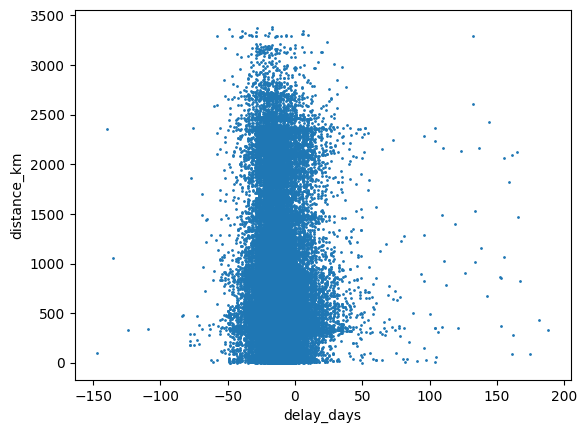

In [61]:
Delay_vs_Distance.plot.scatter(y="distance_km", x="delay_days", s=1)

There is no obvious relationship between distance and delay.

Let's plot only the range [-50, +50] days for a clearer picture.

<Axes: xlabel='distance_km', ylabel='delay_days'>

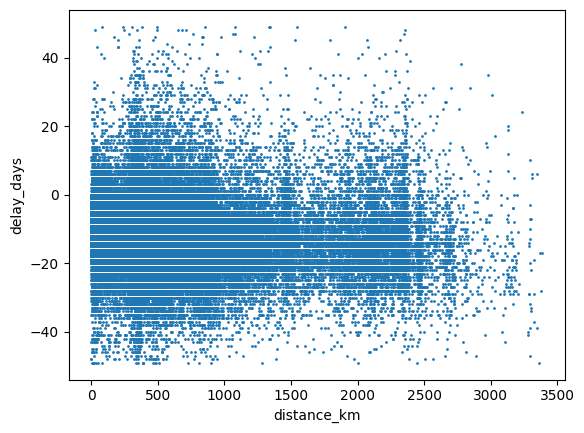

In [62]:
Delay_vs_Distance[(-50 < Delay_vs_Distance.delay_days) & (Delay_vs_Distance.delay_days < 50)].plot.scatter(x="distance_km", y="delay_days", s=1)

There still does not seem to be any link between the two variables.

We now check the proportion of late deliveries for diverse ranges of distances

In [63]:
ranges = np.arange(500, 3501, 500)
percentage_of_late_deliveries = []
for maxi in ranges:
    tmp = Delay_vs_Distance[Delay_vs_Distance.distance_km < maxi]
    percentage = 100* len(tmp[tmp.delivery_status != "On Time"]) / len(tmp)
    percentage_of_late_deliveries.append(percentage)

In [64]:
categories = [str(maxi-500)+'-'+str(maxi) for maxi in ranges]

/tmp/ipykernel_10752/2293093590.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


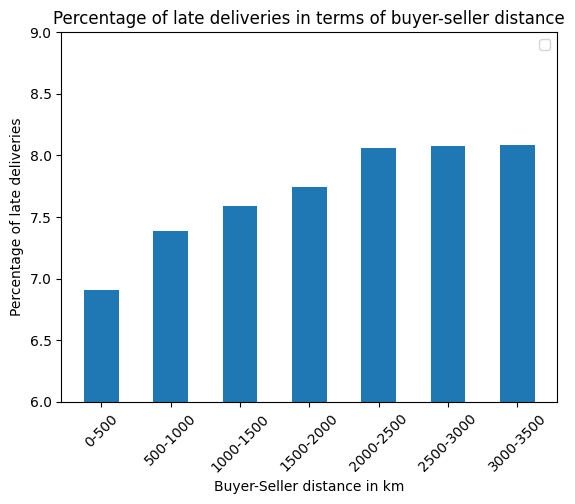

In [65]:
plt.bar(x=categories, height=percentage_of_late_deliveries, width=0.5)
plt.ylim([6, 9])
plt.xticks(rotation=45)
plt.xlabel("Buyer-Seller distance in km")
plt.ylabel("Percentage of late deliveries")
plt.title("Percentage of late deliveries in terms of buyer-seller distance")
plt.legend()
plt.savefig("Percentage of late deliveries in terms of buyer-seller distance.eps", format="eps", transparent=True)
plt.show()

The difference is only of 1%. We can safely conclude that the distance between buyer and seller does not affect the delivery performance in any significant way.

# Story 4: The Sentiment Correlation


**As a** Customer Success Lead,
**I want** to see if late deliveries actually cause bad reviews,
**So that** I can prove to the CEO that logistics is the problem.

- **Acceptance Criteria:**
  - Create a visualization comparing "Delivery Delay (Days)" vs "Average Review Score (1-5)".
  - Show the average review score for "On Time" orders vs. "Late" orders.


Here,
- We plot the average review score for each day of delay (a positive delay means the order is late), then for each week of delay for clarity.
- We find the average delay per delivery status (On Time, Late, and Super Late)

In [66]:
delay_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96999 entries, 0 to 99991
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       96999 non-null  object         
 1   customer_id                    96999 non-null  object         
 2   order_status                   96999 non-null  object         
 3   order_purchase_timestamp       96999 non-null  object         
 4   order_approved_at              96985 non-null  object         
 5   order_delivered_carrier_date   96998 non-null  object         
 6   order_delivered_customer_date  96999 non-null  datetime64[ns] 
 7   order_estimated_delivery_date  96999 non-null  datetime64[ns] 
 8   customer_unique_id             96999 non-null  object         
 9   customer_zip_code_prefix       96999 non-null  int64          
 10  customer_city                  96999 non-null  object         
 11  custome

In [67]:
delay_data.review_score.describe()

,review_score
count,96353.000000
mean,4.155688
std,1.284979
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [68]:
delay_and_review = delay_data[delay_data.review_score.notna()]
delay_and_review.shape

(96353, 20)

In [69]:
delay_and_review["Delivery Delay (Days)"] = (-delay_and_review["Days_Difference"]).dt.days
np.random.seed(473238)
delay_and_review[["Days_Difference", "Delivery Delay (Days)"]].sample(5)

/tmp/ipykernel_10752/1677825857.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delay_and_review["Delivery Delay (Days)"] = (-delay_and_review["Days_Difference"]).dt.days


,Days_Difference,Delivery Delay (Days)
51247,9 days 02:43:01,-10
40608,15 days 04:27:45,-16
58622,-5 days +03:22:26,4
77854,16 days 10:32:42,-17
50968,16 days 11:06:28,-17


In [70]:
delay_and_review = delay_and_review[["Delivery Delay (Days)", "delivery_status", "review_score"]]
np.random.seed(4829021)
delay_and_review.sample(5)

,Delivery Delay (Days),delivery_status,review_score
7945,-20,On Time,3.0
12667,-18,On Time,5.0
37247,-11,On Time,4.0
24650,-26,On Time,5.0
52527,5,Super Late,4.0


In [71]:
delayDays_vs_review = delay_and_review[["Delivery Delay (Days)", "review_score"]].groupby("Delivery Delay (Days)").mean()
delayDays_vs_review.rename(columns={"review_score": "Average Review Score (1-5)"}, inplace=True)
delayDays_vs_review = delayDays_vs_review.reset_index()

In [72]:
delayDays_vs_review.sample(5)

,Delivery Delay (Days),Average Review Score (1-5)
193,167,1.000000
117,35,1.583333
55,-27,4.225647
152,74,1.000000
9,-76,5.000000


/tmp/ipykernel_10752/176582961.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


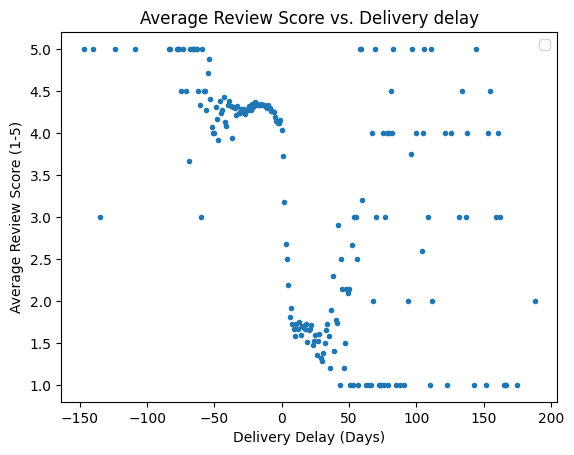

In [73]:
delayDays_vs_review.plot.scatter(x="Delivery Delay (Days)", y="Average Review Score (1-5)", s=9)
plt.title("Average Review Score vs. Delivery delay")
plt.legend()
plt.savefig("Review_1.eps", format="eps", transparent=True)
plt.show()

In [74]:
def binning(row):
    day = 7
    days = row["Delivery Delay (Days)"]
    return math.ceil(days/day)*day

In [75]:
delayDays_vs_review["bins"] = delayDays_vs_review.apply(binning, axis=1)

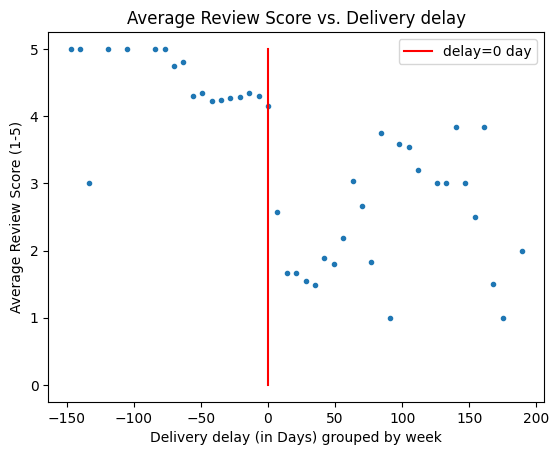

In [76]:
delayDays_vs_review.groupby("bins").mean().reset_index().plot.scatter(x="bins", y="Average Review Score (1-5)", s=9)
plt.plot([0,0], [0,5], color="r", label="delay=0 day")
plt.xlabel("Delivery delay (in Days) grouped by week")
plt.title("Average Review Score vs. Delivery delay")
plt.legend()
plt.savefig("Review_2.eps", format="eps", transparent=True)
plt.show()

In [77]:
# On Time vs Late
delay_and_review.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96353 entries, 0 to 99991
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Delivery Delay (Days)  96353 non-null  int64  
 1   delivery_status        96353 non-null  object 
 2   review_score           96353 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 2.9+ MB


In [78]:
review_vs_delivery_status = delay_and_review[["delivery_status", "review_score"]].groupby("delivery_status").mean()
review_vs_delivery_status.rename(columns={"review_score": "Average Review Score"}, inplace=True)
review_vs_delivery_status

,Average Review Score
delivery_status,
Late,3.460658
On Time,4.293718
Super Late,1.787901


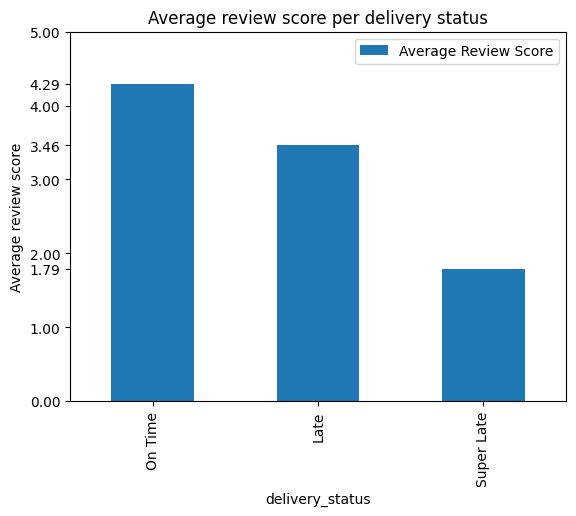

In [79]:
review_vs_delivery_status = review_vs_delivery_status.loc[["On Time", "Late", "Super Late"]]
review_vs_delivery_status.plot.bar(label="Average Review Score")
plt.yticks([0,1,2,3,4,5] + list(round(review_vs_delivery_status["Average Review Score"], 2)))
# put on time on the left
plt.ylabel("Average review score")
plt.title("Average review score per delivery status")
plt.legend()
plt.savefig("Review_3.eps", format="eps", transparent=True)
plt.show()


It appears there is a decrease in user satisfaction as the orders are delayed.
- by almost one review point where the orders are "Late"
- by 2.5 points when they are "Super Late"

# Bonus User Story: The "Translation" Challenge


In [80]:
products = pd.read_csv('olist_products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')

In [81]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [82]:
translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [83]:
products = pd.merge(products, translation, on="product_category_name", how="left")

In [84]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     32951 non-null  object 
 1   product_category_name          32341 non-null  object 
 2   product_name_lenght            32341 non-null  float64
 3   product_description_lenght     32341 non-null  float64
 4   product_photos_qty             32341 non-null  float64
 5   product_weight_g               32949 non-null  float64
 6   product_length_cm              32949 non-null  float64
 7   product_height_cm              32949 non-null  float64
 8   product_width_cm               32949 non-null  float64
 9   product_category_name_english  32328 non-null  object 
dtypes: float64(7), object(3)
memory usage: 2.5+ MB


In [85]:
# To do: delivery_delay by category

# The "Candidate's Choice" Challenge

**As a** Creative Problem Solver,
**I want** to include one extra feature or analysis that adds specific business value,
**So that** I can demonstrate my ability to think beyond the basic requirements.

- **Instructions:**
  - Add one more metric, chart, or drill-down.
  - **Requirement:** You must justify _why_ this feature matters to the business in your README.


We try to find the part of the process that causes the delays.
For that, we find the durations:
- from purchase to approved
- from approved to delivered to carrier
- from carrier to delivered to customer

We then plot their averages per delivery status (On Time, Late, and Super Late).


In [86]:
delay_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96999 entries, 0 to 99991
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       96999 non-null  object         
 1   customer_id                    96999 non-null  object         
 2   order_status                   96999 non-null  object         
 3   order_purchase_timestamp       96999 non-null  object         
 4   order_approved_at              96985 non-null  object         
 5   order_delivered_carrier_date   96998 non-null  object         
 6   order_delivered_customer_date  96999 non-null  datetime64[ns] 
 7   order_estimated_delivery_date  96999 non-null  datetime64[ns] 
 8   customer_unique_id             96999 non-null  object         
 9   customer_zip_code_prefix       96999 non-null  int64          
 10  customer_city                  96999 non-null  object         
 11  custome

In [87]:
Duration = delay_data[delay_data["order_approved_at"].notna() & delay_data["order_delivered_carrier_date"].notna()].copy()

In [88]:
# Convert the relevant columns to datetime, and make sure no null value was introduced during conversion
Duration["order_purchase_timestamp"] = pd.to_datetime(Duration["order_purchase_timestamp"])
Duration["order_approved_at"] = pd.to_datetime(Duration["order_approved_at"])
Duration["order_delivered_carrier_date"] = pd.to_datetime(Duration["order_delivered_carrier_date"])

if Duration[Duration.order_purchase_timestamp.isna()].size == 0:
    print("All right: order_purchase_timestamp converted successfully")
else:
    print("Issues with order_purchase_timestamp")

if Duration[Duration.order_approved_at.isna()].size == 0:
    print("All right: order_approved_at converted successfully")
else:
    print("Issues with order_approved_at")

if Duration[Duration.order_delivered_carrier_date.isna()].size == 0:
    print("All right: order_delivered_carrier_date converted successfully")
else:
    print("Issues with order_delivered_carrier_date")

All right: order_purchase_timestamp converted successfully
All right: order_approved_at converted successfully
All right: order_delivered_carrier_date converted successfully


In [89]:
Duration["purchased_to_approved"] = Duration.order_approved_at - Duration.order_purchase_timestamp
Duration["approved_to_carrier"] =  Duration.order_delivered_carrier_date - Duration.order_approved_at
Duration["carrier_to_customer"] = Duration.order_delivered_customer_date - Duration.order_delivered_carrier_date

In [90]:
Duration = Duration[["delivery_status", "Days_Difference", "purchased_to_approved", "approved_to_carrier", "carrier_to_customer"]]
Duration.sample(5)

,delivery_status,Days_Difference,purchased_to_approved,approved_to_carrier,carrier_to_customer
9586,On Time,6 days 03:27:16,0 days 00:17:22,2 days 06:02:50,4 days 09:25:44
50410,On Time,17 days 07:18:40,0 days 00:12:24,0 days 23:54:55,11 days 01:51:20
18945,On Time,27 days 08:33:03,0 days 00:25:15,2 days 15:23:43,4 days 01:05:57
35406,On Time,15 days 01:11:14,0 days 02:51:09,3 days 14:21:41,14 days 05:15:15
43562,On Time,13 days 22:27:19,0 days 00:11:11,6 days 11:38:27,8 days 02:43:50


In [91]:
Duration_avg = Duration.groupby("delivery_status").mean()
Duration_avg["purchased_to_approved"] = Duration_avg["purchased_to_approved"].dt.days
Duration_avg["approved_to_carrier"] = Duration_avg["approved_to_carrier"].dt.days
Duration_avg["carrier_to_customer"] = Duration_avg["carrier_to_customer"].dt.days
Duration_avg

,Days_Difference,purchased_to_approved,approved_to_carrier,carrier_to_customer
delivery_status,,,,
Late,-3 days +20:57:05.331038282,0,4,17
On Time,13 days 00:14:46.065507181,0,2,7
Super Late,-16 days +01:53:35.631703284,0,5,33


On average,
- it takes less than a day for an order to be approved, and late orders are not different,
- there is a slight difference between on time and late orders when it comes to the time to shipping,
- there is a considerable difference in the time from shipment to delivery to customer.

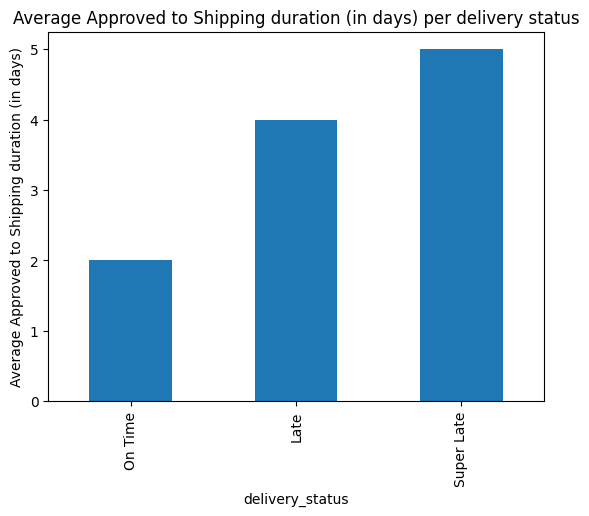

In [92]:
Duration_avg["approved_to_carrier"].loc[["On Time", "Late", "Super Late"]].plot.bar()
plt.ylabel("Average Approved to Shipping duration (in days)")
plt.title("Average Approved to Shipping duration (in days) per delivery status")
plt.show()

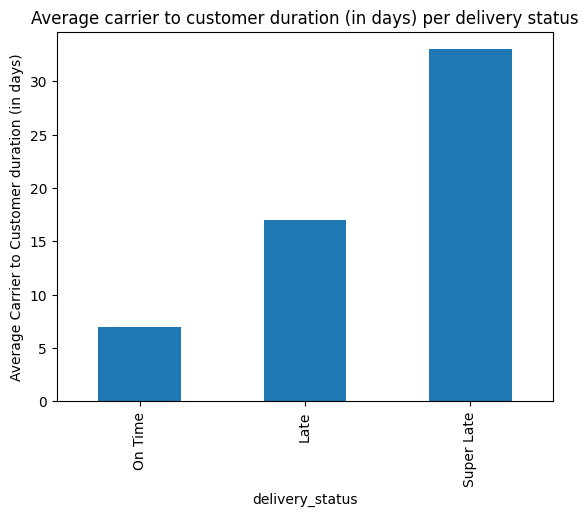

In [93]:
Duration_avg["carrier_to_customer"].loc[["On Time", "Late", "Super Late"]].plot.bar()
plt.ylabel("Average Carrier to Customer duration (in days)")
plt.title("Average carrier to customer duration (in days) per delivery status")
plt.savefig("Average carrier to customer duration (in days) per delivery status.eps", format="eps", transparent=True)
plt.show()

It is clear that the bottleneck is the time it takes the carrier to deliver the packages to the customers.

# Conclusion

1. There is an overall decrease in user satisfaction as packages are late. On average, 1 review point is lost in the first 5 days of delay. The later the packages come, the more disatisfied are customers.

2. The total proportion of late orders is less than 10%.
    - However, it affects the states of Alagoas and Maranhão disproportionately (in the north east region). Respectively 25% and 20% of the orders from those states are late.
    - The distance between buyers and sellers does not affect the delivery delays.

3. An investigation of the duration of each stage of the process shows that by far, the largest delays occur between delivery to the carrier and delivery to the customer.
At least 10 days would be gained on average if that bottleneck was resolved.